# Hospital Readmission Prediction (30-day) + HSE Cost Analysis

**MSc Data Analytics — Domain Applications**

The goal is to predict whether a diabetic patient will be readmitted to hospital
within 30 days, using the UCI *Diabetes 130-US Hospitals (1999–2008)* dataset
(101,766 encounters).

I then take it a step further: the predicted probabilities are turned into
Low / Medium / High risk tiers, each tier is mapped to an Irish HSE follow-up
pathway, and I estimate the cost that could be saved by acting on the higher tiers.

**Steps:** 1) EDA → 2) preprocessing → 3) feature selection (RFE) → 4) SMOTE →
5) modelling (LightGBM + Logistic Regression) → 6) risk tiers → 7) cost analysis.

*To run:* put `diabetic_data.csv` in the same folder and run all cells top to bottom.

## 0. Setup

Import the libraries and fix one random seed so the results are reproducible.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid')
RND = 42   # random seed
pd.set_option('display.max_columns', 60)

# Phase 1 — Data prep & EDA

## 1.1 Load the data

Treat `?` as missing, but keep the literal string `None` as a real category
(for some columns "None" is a genuine value, not a blank).

In [2]:
# '?' = missing, but keep 'None' as a real category
df = pd.read_csv('diabetic_data.csv', na_values=['?'], keep_default_na=False, low_memory=False)
df = df.replace('', np.nan)          # treat any empty strings as missing too

print("Raw shape:", df.shape)        # 101,766 rows x 50 cols
df.head(3)

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


## 1.2 Target variable

The `readmitted` column has three values: `<30`, `>30`, and `NO`.
I only care about 30-day readmission, so the target is 1 if `<30`, else 0.

In [3]:
print(df['readmitted'].value_counts(), "\n")

# Binary 30-day readmission target
df['readmit_30d'] = (df['readmitted'] == '<30').astype(int)
print("Raw 30-day positive rate: %.2f%%" % (100 * df['readmit_30d'].mean()))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64 

Raw 30-day positive rate: 11.16%


## 1.3 Cleaning

Two cleaning steps taken from the original study (Strack et al., 2014):
drop death / hospice discharges (those patients can't be readmitted), and keep
only the first encounter per patient so the same patient doesn't appear twice.

In [4]:
# drop death/hospice discharges (can't be readmitted)
death_hospice = {11, 13, 14, 19, 20, 21}
n0 = len(df)
df = df[~df['discharge_disposition_id'].isin(death_hospice)].copy()
print(f"Removed death/hospice encounters: {n0 - len(df):,}  ->  {len(df):,} rows")

# keep first encounter per patient (avoids leakage)
n0 = len(df)
df = df.sort_values('encounter_id').drop_duplicates('patient_nbr', keep='first').copy()
print(f"Removed repeat encounters:        {n0 - len(df):,}  ->  {len(df):,} rows (analytic cohort)")

print(f"\nAnalytic-cohort 30-day readmission rate: {100 * df['readmit_30d'].mean():.2f}%")

Removed death/hospice encounters: 2,423  ->  99,343 rows


Removed repeat encounters:        29,353  ->  69,990 rows (analytic cohort)

Analytic-cohort 30-day readmission rate: 8.98%


> Keeping only the first encounter lowers the readmission rate from ~11% to ~9%.

## 1.4 Decode the ID codes

`admission_type_id`, `discharge_disposition_id` and `admission_source_id` are
stored as numbers. I map them to readable labels.

In [5]:
admission_type_map = {
    1:'Emergency', 2:'Urgent', 3:'Elective', 4:'Newborn',
    5:'Not Available', 6:'Not Available', 7:'Trauma Center', 8:'Not Mapped'}

discharge_map = {
    1:'Home', 2:'Another short-term hospital', 3:'Skilled Nursing Facility (SNF)',
    4:'Intermediate Care Facility', 5:'Another inpatient institution',
    6:'Home + home health service', 7:'Left against medical advice',
    8:'Home under IV provider care', 9:'Admitted as inpatient here',
    10:'Neonatal aftercare transfer', 12:'Still patient / outpatient return',
    15:'Medicare swing bed', 16:'Outpatient services (other inst.)',
    17:'Outpatient services (this inst.)', 18:'Unknown', 22:'Rehab facility',
    23:'Long-term care hospital', 24:'Medicaid nursing facility',
    25:'Not Mapped', 26:'Unknown', 27:'Federal health care facility',
    28:'Psychiatric hospital', 29:'Critical Access Hospital', 30:'Other institution'}

admission_source_map = {
    1:'Physician referral', 2:'Clinic referral', 3:'HMO referral',
    4:'Transfer from hospital', 5:'Transfer from SNF',
    6:'Transfer from other facility', 7:'Emergency room', 8:'Court/law enforcement',
    9:'Not Available', 10:'Transfer from critical access hospital',
    11:'Normal delivery', 13:'Sick baby', 14:'Extramural birth',
    15:'Not Available', 17:'Unknown', 18:'Transfer from home health agency',
    19:'Readmission to home health agency', 20:'Not Mapped', 21:'Unknown',
    22:'Transfer from same-facility inpatient', 23:'Born inside this hospital',
    24:'Born outside this hospital', 25:'Transfer from ambulatory surgery',
    26:'Transfer from hospice'}

df['admission_type_id']        = df['admission_type_id'].map(admission_type_map).fillna('Unknown')
df['discharge_disposition_id'] = df['discharge_disposition_id'].map(discharge_map).fillna('Unknown')
df['admission_source_id']      = df['admission_source_id'].map(admission_source_map).fillna('Unknown')

print(df['discharge_disposition_id'].value_counts().head(6))

discharge_disposition_id
Home                              44322
Skilled Nursing Facility (SNF)     8790
Home + home health service         8291
Unknown                            2474
Another short-term hospital        1541
Rehab facility                     1411
Name: count, dtype: int64


## 1.5 EDA

### Target balance

Only about 9% of patients are readmitted within 30 days, so the classes are
imbalanced. I handle this later with SMOTE.

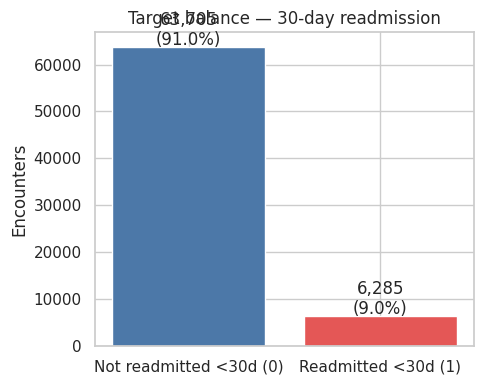

In [6]:
vc = df['readmit_30d'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Not readmitted <30d (0)', 'Readmitted <30d (1)'], vc.values, color=['#4C78A8', '#E45756'])
for i, v in enumerate(vc.values):
    ax.text(i, v + 400, f"{v:,}\n({100*v/len(df):.1f}%)", ha='center')
ax.set_title('Target balance — 30-day readmission'); ax.set_ylabel('Encounters')
plt.tight_layout(); plt.show()

### Missing values

`weight` (~96% missing) and `payer_code` (~43%, administrative) are mostly empty,
so I drop them.

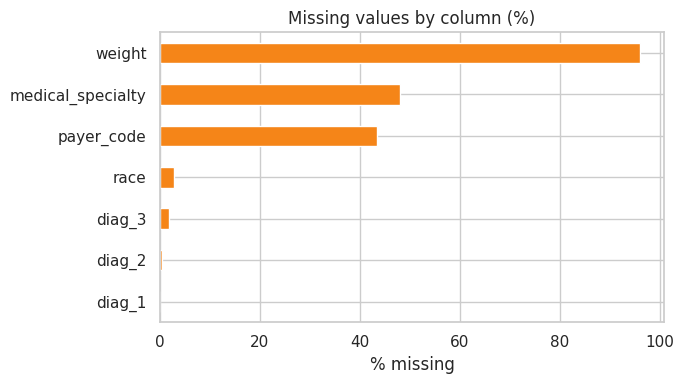

weight               96.02
medical_specialty    48.08
payer_code           43.46
race                  2.74
diag_3                1.75
diag_2                0.42
diag_1                0.01
dtype: float64

In [7]:
miss = (df.isna().mean() * 100)
miss = miss[miss > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
miss.plot(kind='barh', ax=ax, color='#F58518'); ax.invert_yaxis()
ax.set_title('Missing values by column (%)'); ax.set_xlabel('% missing')
plt.tight_layout(); plt.show()
miss.round(2)

### Numeric feature distributions

Most of the count features are right-skewed — lots of zeros with a long tail
(e.g. `number_inpatient`, `number_emergency`).

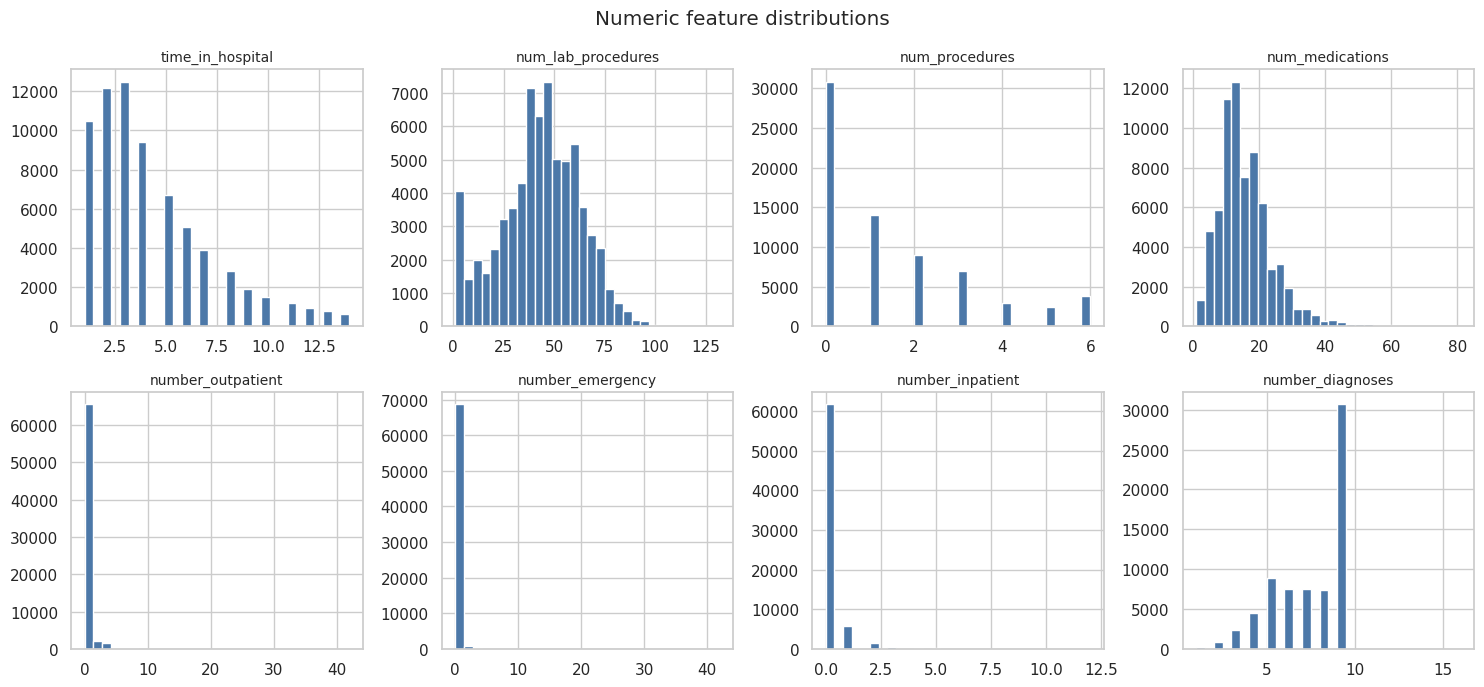

In [8]:
num_cols = ['time_in_hospital','num_lab_procedures','num_procedures','num_medications',
            'number_outpatient','number_emergency','number_inpatient','number_diagnoses']
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for col, ax in zip(num_cols, axes.ravel()):
    ax.hist(df[col], bins=30, color='#4C78A8'); ax.set_title(col, fontsize=10)
plt.suptitle('Numeric feature distributions'); plt.tight_layout(); plt.show()

### What drives readmission

Readmission risk rises with age, and rises sharply with the number of prior
inpatient visits.

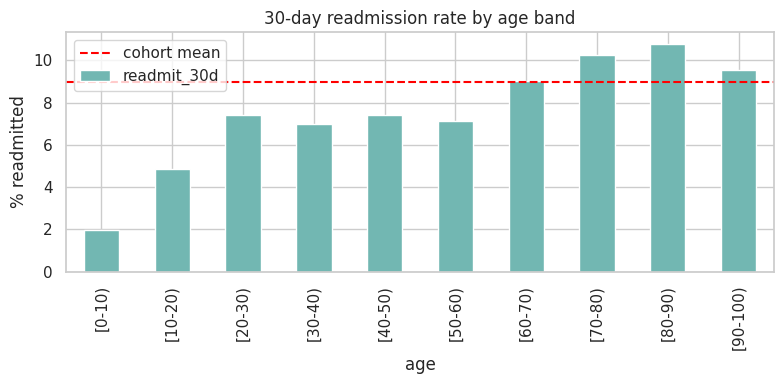

In [9]:
age_order = ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
             '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']
fig, ax = plt.subplots(figsize=(8, 4))
(df.groupby('age')['readmit_30d'].mean().reindex(age_order) * 100).plot(kind='bar', ax=ax, color='#72B7B2')
ax.axhline(100 * df['readmit_30d'].mean(), color='red', ls='--', label='cohort mean')
ax.set_title('30-day readmission rate by age band'); ax.set_ylabel('% readmitted'); ax.legend()
plt.tight_layout(); plt.show()

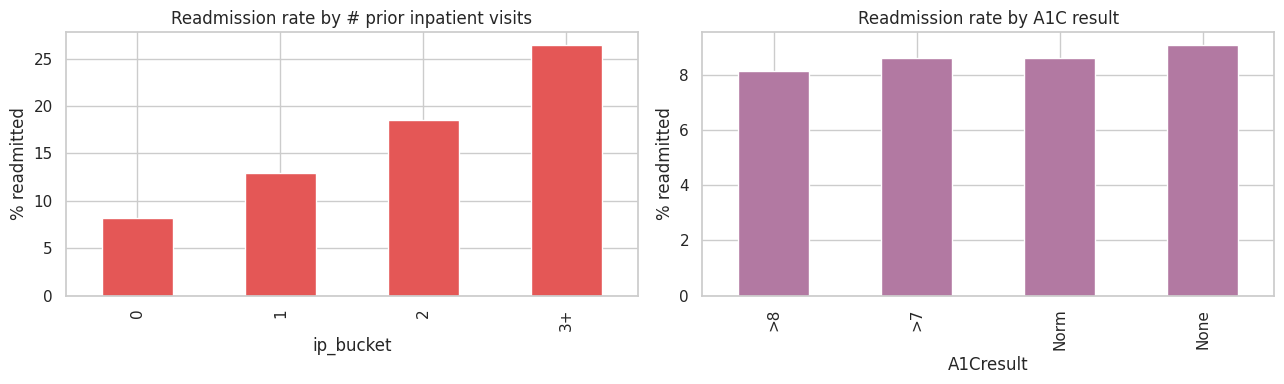

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ip = df.copy()
ip['ip_bucket'] = np.where(df['number_inpatient'] >= 3, '3+', df['number_inpatient'].astype(str))
(ip.groupby('ip_bucket')['readmit_30d'].mean().reindex(['0','1','2','3+']) * 100).plot(
    kind='bar', ax=axes[0], color='#E45756')
axes[0].set_title('Readmission rate by # prior inpatient visits'); axes[0].set_ylabel('% readmitted')
(df.groupby('A1Cresult')['readmit_30d'].mean() * 100).sort_values().plot(
    kind='bar', ax=axes[1], color='#B279A2')
axes[1].set_title('Readmission rate by A1C result'); axes[1].set_ylabel('% readmitted')
plt.tight_layout(); plt.show()

### Readmission by discharge type

Once the codes are decoded, discharge destination is easy to read: patients sent
to rehab / skilled-nursing facilities are readmitted more than those sent home.

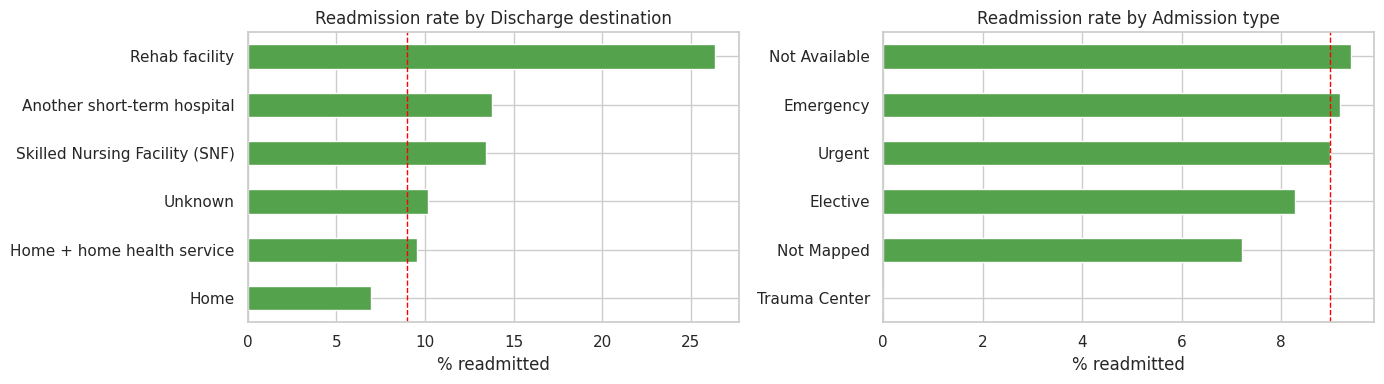

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4)); cohort = 100 * df['readmit_30d'].mean()
for ax, col, title in [(axes[0], 'discharge_disposition_id', 'Discharge destination'),
                       (axes[1], 'admission_type_id', 'Admission type')]:
    top = df[col].value_counts().head(6).index
    rate = (df[df[col].isin(top)].groupby(col)['readmit_30d'].mean() * 100).sort_values()
    rate.plot(kind='barh', ax=ax, color='#54A24B')
    ax.axvline(cohort, color='red', ls='--', lw=1)
    ax.set_title(f'Readmission rate by {title}'); ax.set_xlabel('% readmitted'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

### Correlations

The numeric features are only weakly correlated, so no serious multicollinearity
to worry about.

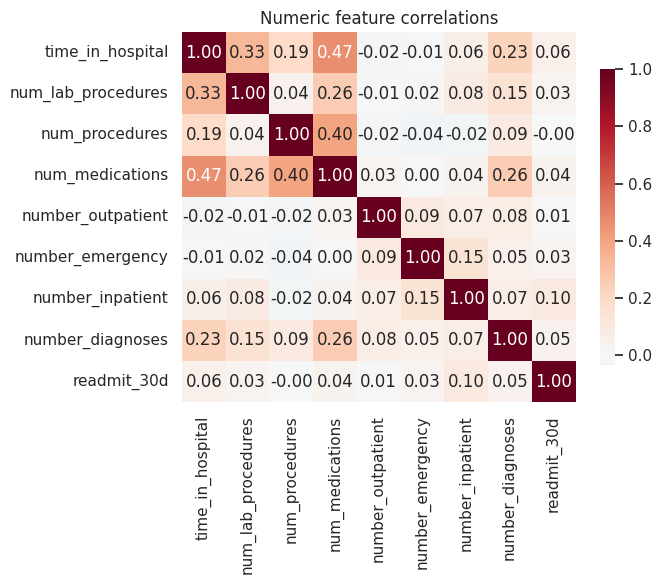

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[num_cols + ['readmit_30d']].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Numeric feature correlations'); plt.tight_layout(); plt.show()

# Phase 2 — Preprocessing

## 2.1 Group the diagnosis codes

The `diag_1/2/3` columns are raw ICD-9 codes. I group them into 9 clinical
categories (diabetes, circulatory, respiratory, etc.) following Strack et al. (2014).

In [13]:
def map_diag(code):
    # map an ICD-9 code to one of 9 clinical groups
    if pd.isna(code):
        return 'Missing'
    s = str(code)
    if s.startswith(('V', 'E')):          # supplementary V/E codes -> Other
        return 'Other'
    try:
        v = float(s)
    except ValueError:
        return 'Other'
    if 250 <= v < 251:                    # 250.xx = diabetes
        return 'Diabetes'
    iv = int(v)
    if (390 <= iv <= 459) or iv == 785: return 'Circulatory'
    if (460 <= iv <= 519) or iv == 786: return 'Respiratory'
    if (520 <= iv <= 579) or iv == 787: return 'Digestive'
    if 800 <= iv <= 999:                return 'Injury'
    if 710 <= iv <= 739:                return 'Musculoskeletal'
    if (580 <= iv <= 629) or iv == 788: return 'Genitourinary'
    if 140 <= iv <= 239:                return 'Neoplasms'
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_grp'] = df[col].apply(map_diag)

df['diag_1_grp'].value_counts()

diag_1_grp
Circulatory        21390
Other              12124
Respiratory         9491
Digestive           6488
Diabetes            5748
Injury              4696
Musculoskeletal     4064
Genitourinary       3441
Neoplasms           2538
Missing               10
Name: count, dtype: int64

## 2.2 Turn age into a number

`age` is stored in 10-year bands. I replace each band with its midpoint
(5, 15, … 95) so it can be used as a numeric feature.

In [14]:
age_mid = {'[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35, '[40-50)':45,
           '[50-60)':55, '[60-70)':65, '[70-80)':75, '[80-90)':85, '[90-100)':95}
df['age_ord'] = df['age'].map(age_mid)

## 2.3 Drop columns

Drop the IDs, `weight`, `payer_code`, and any drug columns that are almost always
the same value (no useful signal).

In [15]:
drug_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
 'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone','rosiglitazone',
 'acarbose','miglitol','troglitazone','tolazamide','examide','citoglipton','insulin',
 'glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
 'metformin-rosiglitazone','metformin-pioglitazone']

# drop drug columns that are almost always the same value
nzv = [c for c in drug_cols if df[c].value_counts(normalize=True).iloc[0] > 0.999]
print("Near-zero-variance drug columns dropped:", nzv)

drop_cols = ['encounter_id','patient_nbr','weight','payer_code','readmitted',
             'age','diag_1','diag_2','diag_3'] + nzv
df = df.drop(columns=drop_cols)
print("Remaining columns:", df.shape[1])

Near-zero-variance drug columns dropped: ['acetohexamide', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Remaining columns: 35


## 2.4 Collapse rare categories

Any category that appears in fewer than 1% of rows becomes `Other`, so one-hot
encoding doesn't blow up the number of columns.

In [16]:
def collapse_rare(s, thresh=0.01, other='Other'):
    '''Replace category levels rarer than `thresh` with a single 'Other' level.'''
    freq = s.value_counts(normalize=True)
    return s.where(s.isin(freq[freq >= thresh].index), other)

df['medical_specialty'] = collapse_rare(df['medical_specialty'].fillna('Missing'), 0.01)
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    df[col] = collapse_rare(df[col], 0.01)
df['race'] = df['race'].fillna('Missing')

## 2.5 Features and target

In [17]:
y = df['readmit_30d']
X = df.drop(columns=['readmit_30d'])

numeric_features = ['age_ord','time_in_hospital','num_lab_procedures','num_procedures',
    'num_medications','number_outpatient','number_emergency','number_inpatient','number_diagnoses']
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features:     9
Categorical features: 25


## 2.6 Train/test split — before any encoding

This is the important bit for a fair result: I split first, so the scaler and the
one-hot encoder only ever see the training data. That prevents data leakage.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RND)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Positive rate - train: {y_train.mean():.4f} | test: {y_test.mean():.4f}")

Train: (55992, 34) | Test: (13998, 34)
Positive rate - train: 0.0898 | test: 0.0898


## 2.7 Encode

Scale the numeric features and one-hot encode the categorical ones. The encoder
is fit on the training set only, then applied to the test set.

In [19]:
pre = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)])

Xtr = pre.fit_transform(X_train)     # fit + transform on TRAIN
Xte = pre.transform(X_test)          # transform only on TEST

feat = np.array(numeric_features +
                list(pre.named_transformers_['cat'].get_feature_names_out(categorical_features)))
print(f"Encoded matrix -> train {Xtr.shape}, test {Xte.shape}  ({len(feat)} features)")

# save the cleaned data
df.to_csv('diabetes_clean.csv', index=False)
print("Saved cleaned cohort -> diabetes_clean.csv")

Encoded matrix -> train (55992, 139), test (13998, 139)  (139 features)


Saved cleaned cohort -> diabetes_clean.csv


# Phase 3 — Feature selection (RFE)

Recursive Feature Elimination repeatedly fits a model and drops the weakest
features. I use it to cut down to 40 features.

In [20]:
rfe = RFE(estimator=LGBMClassifier(n_estimators=100, random_state=RND, n_jobs=-1, verbose=-1),
          n_features_to_select=40, step=10)
rfe.fit(Xtr, y_train)                       # fit on TRAIN only

selected = feat[rfe.support_]
Xtr_sel, Xte_sel = Xtr[:, rfe.support_], Xte[:, rfe.support_]
print(f"Selected {rfe.support_.sum()} of {len(feat)} features:\n")
print(list(selected))

Selected 40 of 139 features:

[np.str_('age_ord'), np.str_('time_in_hospital'), np.str_('num_lab_procedures'), np.str_('num_procedures'), np.str_('num_medications'), np.str_('number_outpatient'), np.str_('number_emergency'), np.str_('number_inpatient'), np.str_('number_diagnoses'), np.str_('race_AfricanAmerican'), np.str_('race_Caucasian'), np.str_('gender_Female'), np.str_('admission_type_id_Emergency'), np.str_('admission_type_id_Urgent'), np.str_('discharge_disposition_id_Another inpatient institution'), np.str_('discharge_disposition_id_Another short-term hospital'), np.str_('discharge_disposition_id_Home'), np.str_('discharge_disposition_id_Rehab facility'), np.str_('discharge_disposition_id_Skilled Nursing Facility (SNF)'), np.str_('admission_source_id_Emergency room'), np.str_('admission_source_id_Physician referral'), np.str_('medical_specialty_InternalMedicine'), np.str_('medical_specialty_Missing'), np.str_('A1Cresult_None'), np.str_('metformin_Steady'), np.str_('insulin_No')

# Phase 4 — Handle the imbalance (SMOTE)

With only ~9% positives, a model can score ~91% accuracy by predicting "no" every
time. SMOTE oversamples the minority class — applied to the training set only.

In [21]:
smote = SMOTE(random_state=RND)
Xtr_bal, y_train_bal = smote.fit_resample(Xtr_sel, y_train)   # resample TRAIN only

print(f"Training rows: {Xtr_sel.shape[0]:,} -> {Xtr_bal.shape[0]:,}")
print(f"Positive rate: {y_train.mean():.3f} (original) -> {y_train_bal.mean():.3f} (balanced)")
print(f"Test set unchanged at {y_test.mean():.3f} positive")

Training rows: 55,992 -> 101,928
Positive rate: 0.090 (original) -> 0.500 (balanced)
Test set unchanged at 0.090 positive


# Phase 5 — Modelling & evaluation

I train two models: **LightGBM** as the main model and **Logistic Regression** as
a simple baseline. Because the data is imbalanced, I tune the probability
threshold for the best F1 score instead of just using 0.5.

In [22]:
def tune_threshold(Xs, ys, factory):
    # pick the threshold with the best F1 on a validation slice
    Xf, Xv, yf, yv = train_test_split(Xs, ys, test_size=0.25, stratify=ys, random_state=RND)
    Xb, yb = SMOTE(random_state=RND).fit_resample(Xf, yf)        # resample the fit-fold only
    pv = factory().fit(Xb, yb).predict_proba(Xv)[:, 1]
    pr, rc, th = precision_recall_curve(yv, pv)
    f1 = 2 * pr * rc / (pr + rc + 1e-9)
    return float(th[np.nanargmax(f1[:-1])])

def evaluate(name, factory):
    # tune threshold, fit on balanced train, score the untouched test set
    thr   = tune_threshold(Xtr_sel, y_train, factory)
    model = factory().fit(Xtr_bal, y_train_bal)
    p     = model.predict_proba(Xte_sel)[:, 1]
    yhat  = (p >= thr).astype(int)
    return {'Model': name, 'AUC-ROC': roc_auc_score(y_test, p),
            'F1': f1_score(y_test, yhat), 'Precision': precision_score(y_test, yhat),
            'Recall': recall_score(y_test, yhat), 'Threshold': thr,
            'F1 @ 0.5': f1_score(y_test, (p >= 0.5).astype(int)),
            '_model': model, '_proba': p}

res_lgbm = evaluate('LightGBM',
    lambda: LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                           random_state=RND, n_jobs=-1, verbose=-1))
res_lr = evaluate('Logistic Regression',
    lambda: LogisticRegression(max_iter=1000, random_state=RND))

summary = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in (res_lgbm, res_lr)]).set_index('Model').round(3)
summary

,AUC-ROC,F1,Precision,Recall,Threshold,F1 @ 0.5
Model,,,,,,
LightGBM,0.646,0.23,0.197,0.274,0.150,0.019
Logistic Regression,0.638,0.22,0.161,0.348,0.574,0.212


The `F1 @ 0.5` column shows how bad the default 0.5 cut-off is here compared to
the tuned threshold.

### ROC and Precision-Recall curves

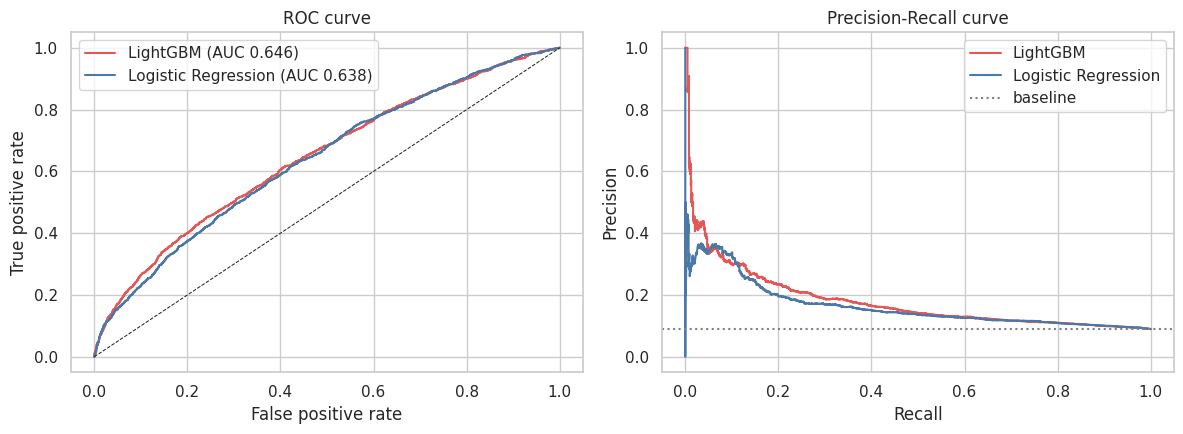

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for r, col in [(res_lgbm, '#E45756'), (res_lr, '#4C78A8')]:
    fpr, tpr, _ = roc_curve(y_test, r['_proba'])
    ax[0].plot(fpr, tpr, color=col, label=f"{r['Model']} (AUC {r['AUC-ROC']:.3f})")
    pr, rc, _ = precision_recall_curve(y_test, r['_proba'])
    ax[1].plot(rc, pr, color=col, label=r['Model'])
ax[0].plot([0, 1], [0, 1], 'k--', lw=.7)
ax[0].set(title='ROC curve', xlabel='False positive rate', ylabel='True positive rate'); ax[0].legend()
ax[1].axhline(y_test.mean(), color='grey', ls=':', label='baseline')
ax[1].set(title='Precision-Recall curve', xlabel='Recall', ylabel='Precision'); ax[1].legend()
plt.tight_layout(); plt.show()

### Confusion matrix — LightGBM at the tuned threshold

For a screening tool, missing a real readmission (false negative) is worse than an
unnecessary follow-up call (false positive).

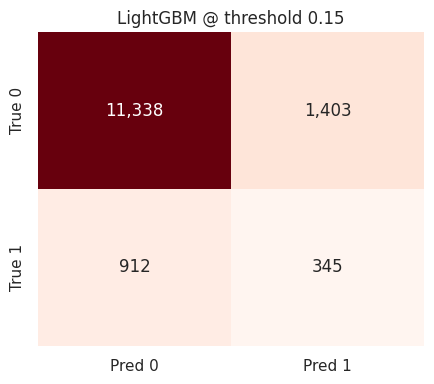

In [24]:
cm = confusion_matrix(y_test, (res_lgbm['_proba'] >= res_lgbm['Threshold']).astype(int))
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Reds', cbar=False,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'], ax=ax)
ax.set_title(f"LightGBM @ threshold {res_lgbm['Threshold']:.2f}"); plt.tight_layout(); plt.show()

### Feature importance

The top features line up with the EDA: prior inpatient visits, number of diagnoses
and medications, and length of stay.

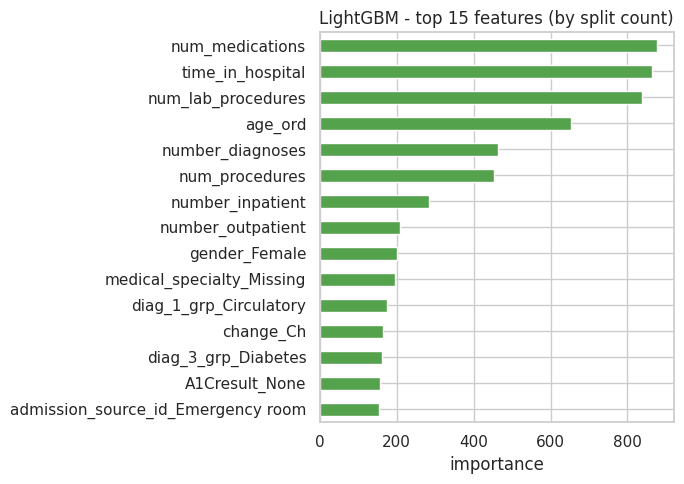

In [25]:
imp = pd.Series(res_lgbm['_model'].feature_importances_, index=selected).sort_values()[-15:]
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot(kind='barh', ax=ax, color='#54A24B')
ax.set_title('LightGBM - top 15 features (by split count)'); ax.set_xlabel('importance')
plt.tight_layout(); plt.show()

### Save the model

Save the full pipeline (preprocessing + feature selection + model) and the tuned
threshold, ready to be reused in an app.

In [26]:
infer = Pipeline([('pre', pre), ('rfe', rfe), ('clf', res_lgbm['_model'])])
joblib.dump({'pipeline': infer, 'threshold': res_lgbm['Threshold'], 'features': list(selected)},
            'lgbm_readmission_model.joblib')
print("Saved -> lgbm_readmission_model.joblib")

Saved -> lgbm_readmission_model.joblib


# Phase 6 — Risk stratification

A single yes/no flag isn't that useful in practice. I turn the predicted
probability into three tiers: Low / Medium / High.

           patients  observed_readmit  % of cohort
risk_tier                                         
Low            8803               6.4         62.9
Medium         4493              11.3         32.1
High            702              26.8          5.0


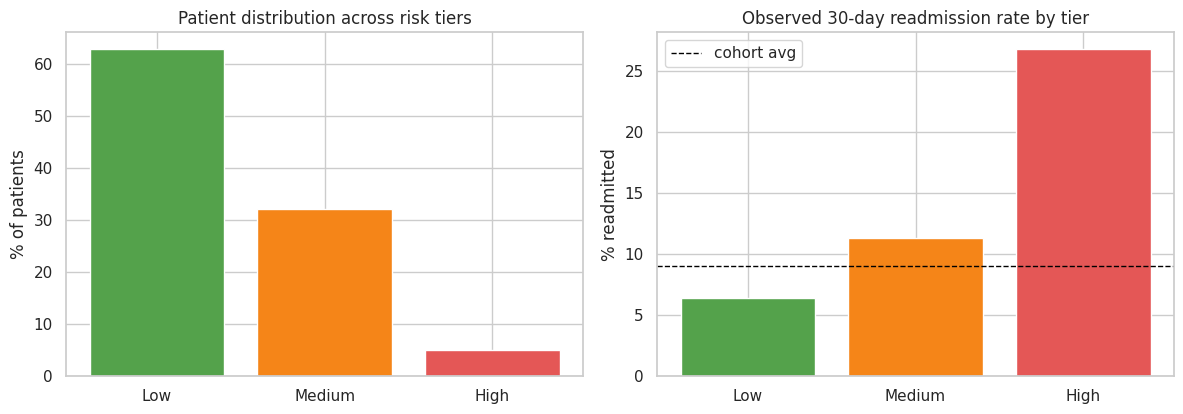

In [27]:
preds = pd.DataFrame({'y_true': y_test.values, 'proba_lgbm': res_lgbm['_proba']})
LOW_CUT, HIGH_CUT = 0.10, 0.20

def assign_tier(p):
    return np.where(p >= HIGH_CUT, 'High', np.where(p >= LOW_CUT, 'Medium', 'Low'))

preds['risk_tier'] = assign_tier(preds['proba_lgbm'])
order = ['Low', 'Medium', 'High']

tier_summary = (preds.groupby('risk_tier')
                .agg(patients=('y_true', 'size'), observed_readmit=('y_true', 'mean'))
                .reindex(order))
tier_summary['% of cohort']      = (100 * tier_summary['patients'] / len(preds)).round(1)
tier_summary['observed_readmit'] = (100 * tier_summary['observed_readmit']).round(1)
print(tier_summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3)); colors = ['#54A24B', '#F58518', '#E45756']
ax[0].bar(order, tier_summary['% of cohort'], color=colors)
ax[0].set(title='Patient distribution across risk tiers', ylabel='% of patients')
ax[1].bar(order, tier_summary['observed_readmit'], color=colors)
ax[1].axhline(100 * preds['y_true'].mean(), color='black', ls='--', lw=1, label='cohort avg')
ax[1].set(title='Observed 30-day readmission rate by tier', ylabel='% readmitted'); ax[1].legend()
plt.tight_layout(); plt.show()

## 6.1 Map the tiers to HSE pathways

Each tier gets an escalating set of real HSE Enhanced Community Care actions.

In [28]:
hse_pathways = pd.DataFrame([
    {'Risk tier':'Low', 'Probability':'< 0.10',
     'HSE post-discharge pathway':
        'Routine discharge: electronic discharge summary to GP; standard self-management '
        'advice; no additional community resource.'},
    {'Risk tier':'Medium', 'Probability':'0.10 - 0.20',
     'HSE post-discharge pathway':
        'Enhanced follow-up: structured Public Health Nurse phone call within 48-72h; '
        'medication reconciliation at discharge; GP early-review request (<=1 week); '
        'documented red-flag escalation advice.'},
    {'Risk tier':'High', 'Probability':'>= 0.20',
     'HSE post-discharge pathway':
        'Intensive intervention: referral to Community Intervention Team (CIT) / Enhanced '
        'Community Care; individualised structured discharge plan; pharmacist-led medication '
        'review; early specialist follow-up (<=7 days); PHN home visit; ICPOP referral where '
        'age-appropriate.'},
]).set_index('Risk tier')

pd.set_option('display.max_colwidth', None)
hse_pathways

,Probability,HSE post-discharge pathway
Risk tier,,
Low,< 0.10,Routine discharge: electronic discharge summary to GP; standard self-management advice; no additional community resource.
Medium,0.10 - 0.20,Enhanced follow-up: structured Public Health Nurse phone call within 48-72h; medication reconciliation at discharge; GP early-review request (<=1 week); documented red-flag escalation advice.
High,>= 0.20,Intensive intervention: referral to Community Intervention Team (CIT) / Enhanced Community Care; individualised structured discharge plan; pharmacist-led medication review; early specialist follow-up (<=7 days); PHN home visit; ICPOP referral where age-appropriate.


## 6.2 One function to score a patient

Give it a probability, it returns the risk tier and the recommended HSE pathway.

In [29]:
def stratify_patient(probability):
    # return the risk tier + HSE pathway for one probability
    tier = str(assign_tier(np.array([probability]))[0])
    return {'probability': round(float(probability), 3),
            'risk_tier': tier,
            'pathway': hse_pathways.loc[tier, 'HSE post-discharge pathway']}

stratify_patient(0.27)      # example: a high-risk patient

{'probability': 0.27,
 'risk_tier': 'High',
 'pathway': 'Intensive intervention: referral to Community Intervention Team (CIT) / Enhanced Community Care; individualised structured discharge plan; pharmacist-led medication review; early specialist follow-up (<=7 days); PHN home visit; ICPOP referral where age-appropriate.'}

# Phase 7 — Cost-impact analysis

The last step turns predictions into a rough estimate of the readmission cost that
could be avoided for the HSE.

## 7.1 Parameters

Bed-day cost and average readmission length of stay come from published Irish/HSE
sources.

In [30]:
BED_DAY_COST  = 878        # HSE acute bed-day cost, 2019
READMIT_LOS   = 5.8        # avg readmission length of stay, Ireland
COST_READMIT  = BED_DAY_COST * READMIT_LOS
EFFECTIVENESS = 0.20       # assumed 20% reduction in readmissions
INTERV_COST   = {'High': 200, 'Medium': 80}    # per-patient cost (assumption)

print(f"Cost per 30-day readmission = EUR {BED_DAY_COST} x {READMIT_LOS} days = EUR {COST_READMIT:,.0f}")

tier = (preds.groupby('risk_tier')
        .agg(n=('y_true', 'size'), readmits=('y_true', 'sum')).reindex(order))
tier

Cost per 30-day readmission = EUR 878 x 5.8 days = EUR 5,092


,n,readmits
risk_tier,,
Low,8803,563
Medium,4493,506
High,702,188


## 7.2 Cost by strategy

Compare treating the High tier only vs High + Medium.

In [31]:
def cost_impact(tiers, effectiveness, cost_per_patient):
    sub          = tier.loc[tiers]
    n_treated    = sub['n'].sum()
    readmits     = sub['readmits'].sum()
    prevented    = readmits * effectiveness
    gross_saving = prevented * COST_READMIT
    interv_cost  = sum(tier.loc[t, 'n'] * cost_per_patient[t] for t in tiers)
    return pd.Series({
        'patients treated':                 int(n_treated),
        'readmissions prevented':           round(prevented, 1),
        'avoided bed-day cost EUR':         round(gross_saving),
        'intervention cost EUR':            round(interv_cost),
        'net saving EUR':                   round(gross_saving - interv_cost),
        'break-even cost/patient EUR':      round(gross_saving / n_treated),
        'cost per readmission prevented EUR': round(interv_cost / prevented)})

results = pd.DataFrame({
    'High only':     cost_impact(['High'],          EFFECTIVENESS, INTERV_COST),
    'High + Medium': cost_impact(['High', 'Medium'], EFFECTIVENESS, INTERV_COST)})
results

,High only,High + Medium
patients treated,702.0,5195.0
readmissions prevented,37.6,138.8
avoided bed-day cost EUR,191474.0,706825.0
intervention cost EUR,140400.0,499840.0
net saving EUR,51074.0,206985.0
break-even cost/patient EUR,273.0,136.0
cost per readmission prevented EUR,3734.0,3601.0


## 7.3 Sensitivity analysis

Effectiveness and per-patient cost are assumptions, so I vary both and check that
the net saving stays positive under realistic values.

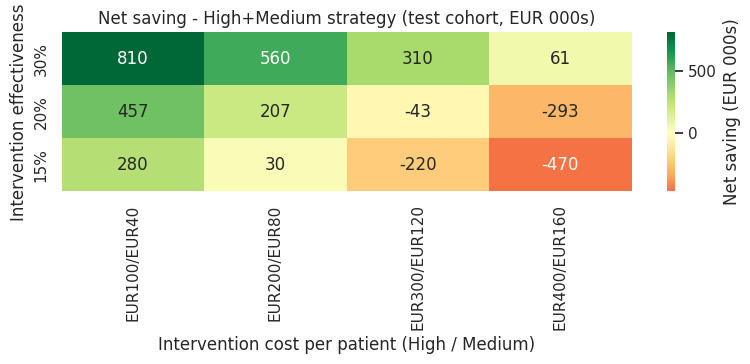

In [32]:
effs  = [0.30, 0.20, 0.15]
mults = [0.5, 1.0, 1.5, 2.0]
labels = [f"EUR{int(200*m)}/EUR{int(80*m)}" for m in mults]

grid = np.array([[ (tier.loc[['High','Medium'], 'readmits'].sum() * e * COST_READMIT
                    - (tier.loc['High','n'] * 200 * m + tier.loc['Medium','n'] * 80 * m)) / 1000
                  for m in mults] for e in effs])

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.heatmap(grid, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            xticklabels=labels, yticklabels=[f"{int(e*100)}%" for e in effs],
            cbar_kws={'label': 'Net saving (EUR 000s)'}, ax=ax)
ax.set(xlabel='Intervention cost per patient (High / Medium)',
       ylabel='Intervention effectiveness',
       title='Net saving - High+Medium strategy (test cohort, EUR 000s)')
plt.tight_layout(); plt.show()

# Conclusion

## Summary of results

| Stage | Result |
|---|---|
| Analytic cohort | 69,990 first-encounter patients (from 101,766 raw) |
| 30-day readmission rate | 8.98% |
| Feature selection | 139 → 40 features (RFE), no AUC loss |
| Main model (LightGBM) | AUC-ROC ≈ 0.646 |
| Baseline (Logistic Regression) | AUC-ROC ≈ 0.638 |
| Risk tiers | Low 6.4% / Medium 11.3% / High 26.8% readmission |
| Cost impact (High+Medium, 20%) | ≈ €207k net saving in the test cohort |

## Limitations

- AUC ≈ 0.65 is about the realistic ceiling for this dataset — the features only
  explain part of readmission risk.
- The data is US (1999–2008); the HSE mapping and costs transfer the *approach* to
  Ireland but would need checking on Irish HIPE data.
- The cost figures rely on assumptions, which is why I include a sensitivity analysis.

## What's next

The saved model is the basis for a small Streamlit app that scores a patient and
shows the recommended HSE pathway.

# References

**Methods**
- Chawla, N.V. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique.
  *Journal of Artificial Intelligence Research*, 16, 321–357.
- Guyon, I. et al. (2002). Gene selection for cancer classification using SVMs.
  *Machine Learning*, 46, 389–422.
- Ke, G. et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree.
  *NeurIPS*.

**Data & domain**
- Strack, B. et al. (2014). Impact of HbA1c measurement on hospital readmission
  rates. *BioMed Research International*, 2014.
- Leppin, A.L. et al. (2014). Preventing 30-day hospital readmissions.
  *JAMA Internal Medicine*, 174(7), 1095–1107.
- Conway, R. et al. (2017). Emergency readmissions, length of stay (Ireland).
- HSE / Oireachtas PQ (2019): average acute bed-day cost.